In [1]:
import pandas as pd
from sqlalchemy import create_engine, text
import urllib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data

Loading data from Azure SQL Server using sqlalchemy.

In [4]:
server = 'sqlserver-fraud-2026.database.windows.net'
database = 'sqldb-fraud'
username = 'adminfraud'
password = 'Qwerty_12'
driver = 'ODBC Driver 17 for SQL Server'

params = urllib.parse.quote_plus(f"DRIVER={driver};SERVER={server};DATABASE={database};UID={username};PWD={password}")
connection_url = f"mssql+pyodbc:///?odbc_connect={params}"


engine = create_engine(connection_url)


try:

    with engine.connect() as conn:
        query_fraud = "SELECT TOP 10 * FROM fraud_features"
        df_fraud = pd.read_sql(text(query_fraud), conn)
        display(df_fraud[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'errorBalanceOrig']].head())

        query_importance = "SELECT * FROM fraud_features"
        df_raw = pd.read_sql(text(query_importance), conn)
    

except Exception as e:
    print(f"Error: {e}")

,amount,oldbalanceOrg,newbalanceOrig,errorBalanceOrig
0,181.0,181.0,0.0,0.00
1,181.0,181.0,0.0,0.00
2,229133.94,15325.0,0.0,-213808.94
3,215310.3,705.0,0.0,-214605.30
4,311685.89,10835.0,0.0,-300850.89


In [6]:
df = df_raw.copy()

# 2. Dataset overview & Summary Statistics

In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0.00,181.0
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0.00,21363.0
2,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,-213808.94,182703.5
3,1,TRANSFER,215310.3,C1670993182,705.0,0.0,C1100439041,22425.0,0.0,0,-214605.30,237735.3
4,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,-300850.89,-2401220.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2770409 entries, 0 to 2770408
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   step              object 
 1   type              object 
 2   amount            object 
 3   nameOrig          object 
 4   oldbalanceOrg     object 
 5   newbalanceOrig    object 
 6   nameDest          object 
 7   oldbalanceDest    object 
 8   newbalanceDest    object 
 9   isFraud           object 
 10  errorBalanceOrig  float64
 11  errorBalanceDest  float64
dtypes: float64(2), object(10)
memory usage: 253.6+ MB


**Insights:**  

Columns `step`, `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` and `isFraud` had wrong type I will change it to `float` or `int`.

In [9]:
cols_int = ['step','isFraud']
cols_float = ['amount','oldbalanceOrg', 'newbalanceOrig', 'newbalanceOrig', 'newbalanceDest', 'oldbalanceDest']
for col in cols_int:
    df[col] = df[col].astype(int)
for col in cols_float:
    df[col] = df[col].astype(float)

In [10]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest
count,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06
mean,2.420081e+02,3.175361e+05,4.764308e+04,1.609190e+04,1.703551e+06,2.049734e+06,2.964544e-03,-2.859850e+05,-2.864713e+04
std,1.416191e+02,8.877897e+05,2.513251e+05,1.512558e+05,4.225550e+06,4.676990e+06,5.436687e-02,8.753230e+05,5.934794e+05
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.244552e+07,-7.588573e+07
25%,1.550000e+02,8.297354e+04,0.000000e+00,0.000000e+00,1.280734e+05,3.272891e+05,0.000000e+00,-2.798912e+05,0.000000e+00
50%,2.360000e+02,1.712609e+05,3.039600e+02,0.000000e+00,5.557100e+05,8.280539e+05,0.000000e+00,-1.435971e+05,0.000000e+00
75%,3.320000e+02,3.067912e+05,3.099700e+04,0.000000e+00,1.735900e+06,2.122198e+06,0.000000e+00,-5.185310e+04,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e-02,1.000000e+07


In [11]:
df.describe(include='object')

,type,nameOrig,nameDest
count,2770409,2770409,2770409
unique,2,2768630,509565
top,CASH_OUT,C2098525306,C1286084959
freq,2237500,3,75


In [12]:
df.shape

(2770409, 12)

# 3. Automated Data Quality Audit

Design a custom Python class DataCheck to systematically identyfy missing and duplicated values

In [13]:
class DataCheck:
    def __init__(self,dataframe):
        self.df = dataframe
    def check_missing_values(self):
        missing_values_pct = (self.df.isnull().sum() / len(self.df)) * 100
        return missing_values_pct[missing_values_pct > 1].sort_values(ascending=False).round(2)
    def check_duplicates(self):
        duplicated  = self.df.duplicated().sum()
        return f"Sum of duplicated records in dataset: {duplicated}"


In [14]:
check_df = DataCheck(df)
check_df.check_missing_values()

Series([], dtype: float64)

In [15]:
check_df.check_duplicates()

'Sum of duplicated records in dataset: 0'

**Insights:**  
Dataset not included missing values and duplicates.

# 4. Explanatory Data Analysis

## 4.1 Data Visualizer

Design a custom Python class DataVisualizer to create graphs.

In [16]:
class DataVisualizer:
    def __init__(self, dataframe):
        self.df = dataframe
    def histplots(self, columns, sup_title, n, m):
        sns.set_style('whitegrid')
        fig, axes = plt.subplots(nrows=n, ncols=m, figsize=(15,10))
        fig.suptitle(sup_title)
        axes = axes.flatten()
        for i, (col) in enumerate(columns):
            sns.histplot(self.df[col], kde=True, bins=40, ax=axes[i], log_scale=True)
            axes[i].set_title(f"Distribution of {col}")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Count')
        for j in range(i + 1, n *m):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()
    def countplots(self, columns):
        sns.set_style('whitegrid')
        for i, col in enumerate(columns):
            ax =  sns.countplot(data=self.df, x=col, order=self.df[col].value_counts().index, hue=col, palette='viridis', legend=False)
            for container in ax.containers:
                ax.bar_label(container, fmt = '%.0f', padding=3)
            plt.title(f"Number of {col}")
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.yscale('log')
            plt.xticks(rotation=45)
            plt.show()
    def heatmap(self):
        numeric_cols = self.df.select_dtypes(include='number')
        correlations = numeric_cols.corr()
        plt.figure(figsize=(15,10))
        sns.heatmap(correlations, cmap='inferno', annot=True, fmt='.2f')
        plt.show()
    def kdeplot(self,col1, hue_col):
        sns.set_style('whitegrid')
        plt.figure(figsize=(12,10))
        sns.kdeplot(data=self.df, x=col1, hue=hue_col, multiple='stack', common_norm=False, fill=True, alpha=0.5 )
        plt.title('Fraud Density vs. Time of Day (Step)')
        plt.ylabel('Density')
        plt.xlabel('step')
        plt.yscale('log')
        plt.xticks(range(0,24))
        plt.show()
    def countplots_type(self, col, hue_col):
        ax = sns.countplot(data=self.df, x=col, order =self.df[col].value_counts().index , hue=hue_col, palette='viridis', legend=True)
        for container in ax.containers:
                ax.bar_label(container, fmt = '%.0f', padding=3)
        plt.title(f"{col} vs {hue_col}")
        plt.ylabel('Count')
        plt.yscale('log')
        plt.xlabel(col)
        plt.show()
    def violinplot(self, col, x_col):
        sns.violinplot(data=self.df, x=x_col, y=col,inner='quart')
        plt.yscale('log')
        plt.title(f'{x_col} vs {col}')
        plt.xlabel(x_col)
        plt.ylabel(col)
        plt.show()
    def violinplot_error(self, x_col, columns, sup_title,n,m):
        sns.set_style('whitegrid')
        fig, axes = plt.subplots(nrows=n, ncols=m, figsize=(16,6))
        plt.suptitle(sup_title)
        axes = axes.flatten()
        for i, col in enumerate(columns):
            y_data = self.df[col].abs() + 1e-9
            sns.violinplot(data=self.df, x=x_col, y=y_data, ax=axes[i], inner='quart')
            axes[i].set_yscale('log')
            axes[i].set_title(f"{x_col} vs {col}")
            axes[i].set_ylabel("Absolute")
        for j in range(1 + i, n*m):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()

## 4.2. Univariate Analysis

### 4.2.1 Continous  Variables

In [17]:
continous_var = df[['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','errorBalanceOrig','errorBalanceDest']]

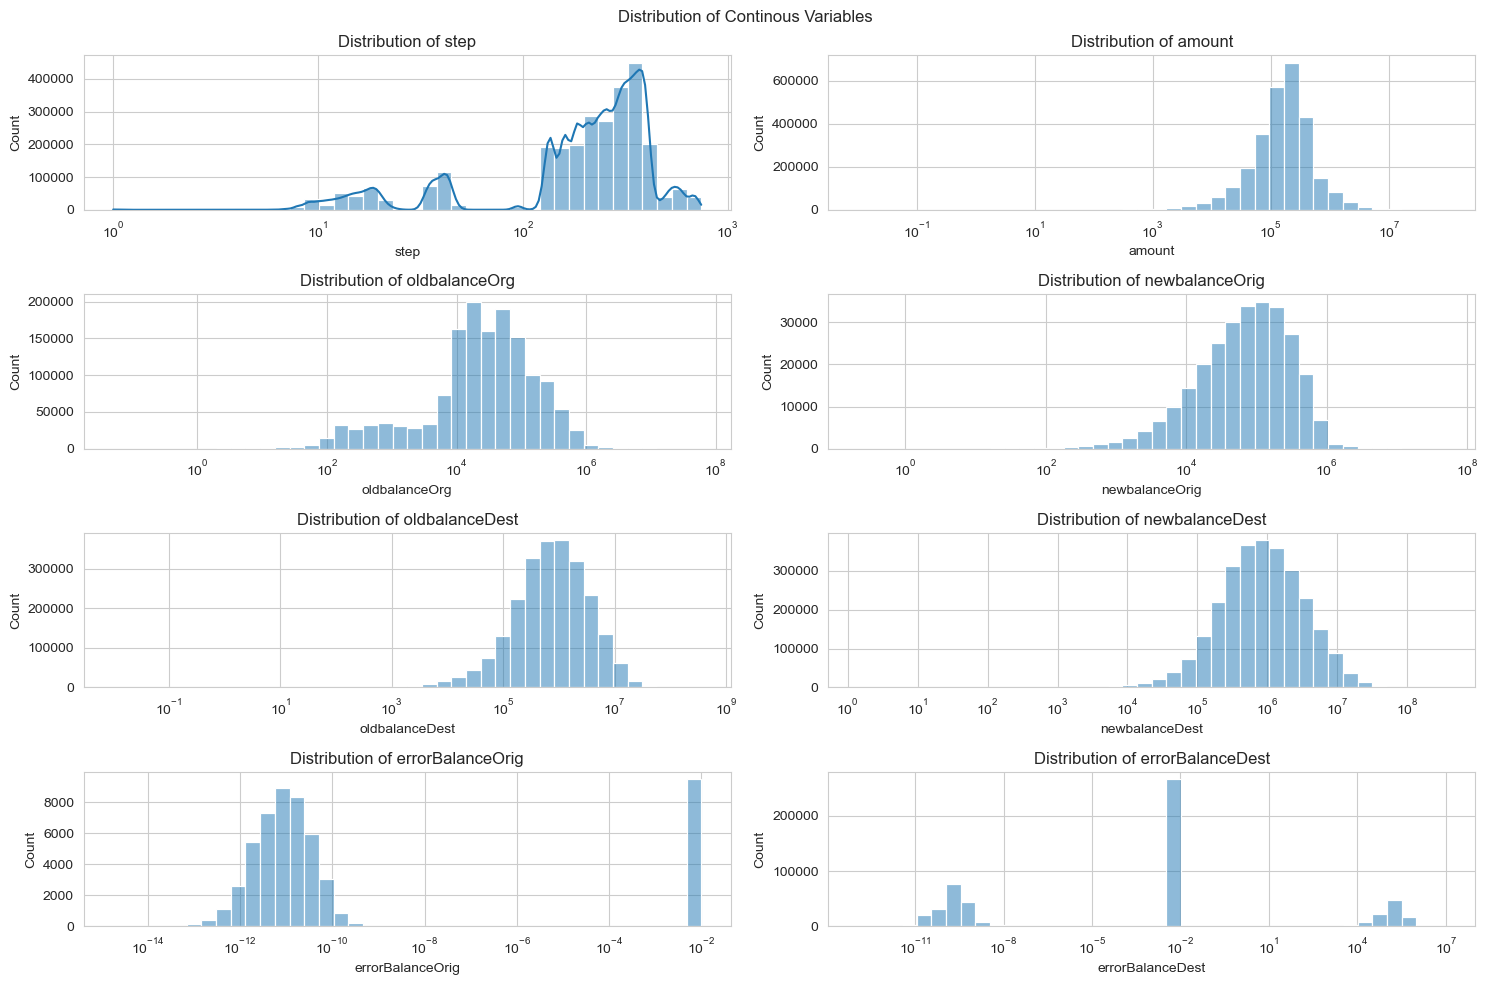

In [18]:
viz_continous = DataVisualizer(df)
viz_continous.histplots(continous_var, 'Distribution of Continous Variables', 4,2 )

**Insighsts:**  
* **Time Variable (`step`):** Applying a logarithmic scale to a time-based feature obscures its natural cyclicality (e.g., daily or weekly patterns). Moving forward, this feature will be analyzed on a linear scale to properly capture temporal trends and recurring fraud patterns.
* **`amount`:** Transaction amounts follow a log-normal distribution, visible as a roughly bell-shaped curve on the logarithmic scale, with the clear majority of transactions clustering around $10^5$ units. This means that on a linear scale, the distribution would be heavily right-skewed — but on the log scale, the moderate symmetry suggests that transaction amounts span several orders of magnitude in a structured, predictable way. Unusually high-value transfers at the tail of the distribution remain a potential fraud signal worth flagging.
* **`oldbalanceOrg` vs `newbalanceOrig`:** Origin accounts in `oldbalanceOrg` show a primary concentration of balances between $10^3$ and $10^5$, representing the core user base with moderate funds. However, there is a distinct, flat "plateau" on the left side of the distribution (between roughly 30 and $10^3$ units), revealing a secondary group of users engaging in micro-transactions with low balances. Notably, very low pre-transaction balances (below $10^1$) are nearly absent. In contrast, `newbalanceOrig` shows a massive disappearance of these lower-end balances from the log-scale plot, indicating that many transactions result in an account balance dropping to exactly zero — a pattern strongly associated with fraudulent activity (Account Takeover). This behavior will be engineered as a dedicated binary feature (e.g., `accountDrained`) in subsequent steps.
* **`oldbalanceDest` vs `newbalanceDest`:** Destination accounts consistently show higher balances than origin accounts, concentrated around $10^6$ units both before and after transactions. This asymmetry may suggest the presence of mule accounts — accounts that aggregate funds from multiple sources — which is a known pattern in money laundering and fraud schemes.
* **`errorBalanceOrig` vs `errorBalanceDest`:** The calculated balance errors reveal a massive cluster at the $10^-12$ mark, which represents exact zeros — these minimal values are purely floating-point precision artifacts in Python, not genuine discrepancies. Crucially, non-zero error values stand out as statistically anomalous and will be treated as a strong fraud indicator in feature engineering.

### 4.2.2 Binary Variable

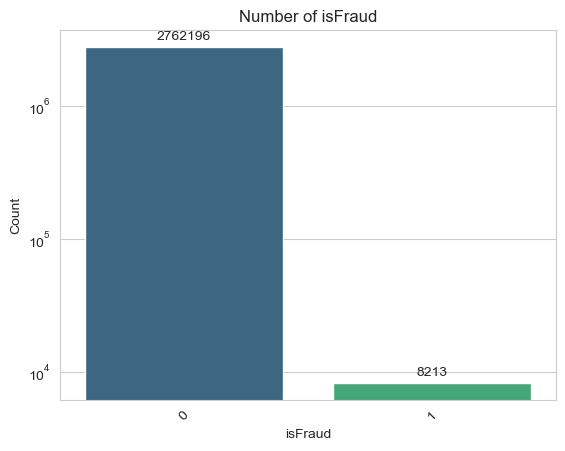

In [19]:
viz_bin = DataVisualizer(df)
viz_bin.countplots(df[['isFraud']])

**Insights:** 
The target variable is severely imbalanced, with fraud representing only a tiny fraction (approx. 0.13%) of all records.

### 4.2.3 Categorical Variable

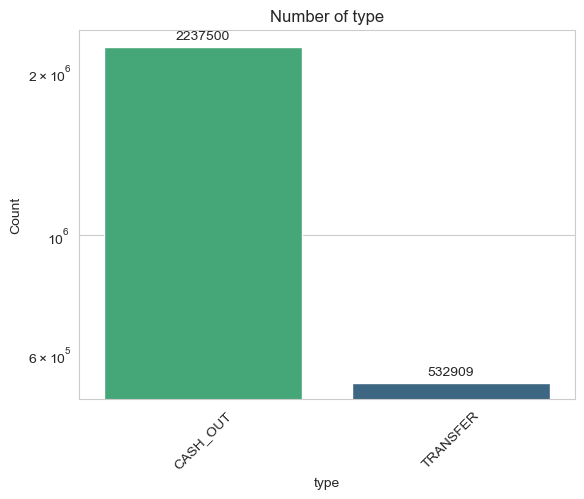

In [20]:
viz_cat = DataVisualizer(df)
viz_cat.countplots(df[['type']])

**Insights:**  
The transaction types are also imbalanced, dominated heavily by `CASH_OUT` (over 2.2M) and `TRANSFER` (over 0.5M).

In [21]:
print('Top 10 sender')
print(df['nameOrig'].value_counts().head(10))

Top 10 sender
nameOrig
C2098525306    3
C724452879     3
C1902386530    3
C275184582     2
C68721948      2
C1876168665    2
C2054218084    2
C396519746     2
C1165998370    2
C1166822525    2
Name: count, dtype: int64


In [22]:
orig_counts = df['nameOrig'].value_counts()
print(orig_counts.value_counts().sort_index())

count
1    2766854
2       1773
3          3
Name: count, dtype: int64


In [23]:
print('Top 10 reciver')
print(df['nameDest'].value_counts().head(10))

Top 10 reciver
nameDest
C1286084959    75
C665576141     68
C1360767589    68
C97730845      67
C248609774     64
C2006081398    63
C2083562754    63
C1789550256    62
C1590550415    62
C1023714065    61
Name: count, dtype: int64


**Insights:**  
* **`nameOrig` (Senders):** Sender behavior is completely normal. The vast majority of origin accounts appear only once in the dataset, with an absolute maximum of 3 transactions per account. 
* **`nameDest` (Receivers):** In stark contrast, top destination accounts receive 60 to 75 transactions. This highly suspicious, aggregator-like behavior strongly suggests the presence of "money mules" within the system.


## 4.3 Correlations 

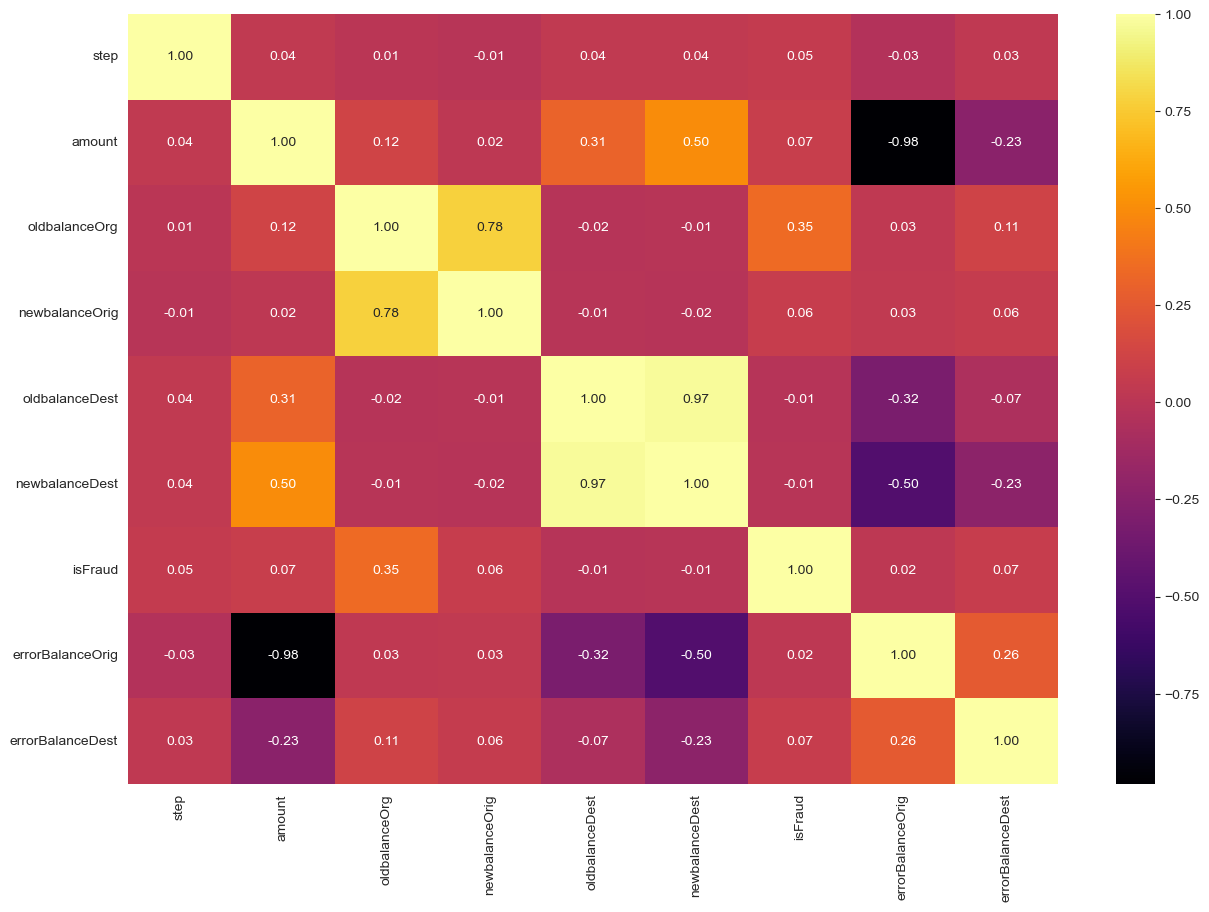

In [24]:
corr_viz = DataVisualizer(df)
corr_viz.heatmap()

**Insights:**  
* **Perfect Multicollinearity in Balances:** There is an extremely strong correlation between raw balances (e.g., `oldbalanceDest` and `newbalanceDest` at 0.97, and `oldbalanceOrg` and `newbalanceOrig` at 0.78). This confirms that raw balances are redundant and justifies dropping them in later stages in favor of engineered features.
* **Mathematical Correlations:** Engineered features naturally correlate with their source variables (e.g., `errorBalanceOrig` and `amount` at -0.98). For tree-based models (like XGBoost), this multicollinearity is not an issue and both features will be retained.
*  **Target Correlations:** Linear correlations with the target (`isFraud`) are inherently very low (mostly between -0.01 and 0.07) due to the extreme class imbalance. The only notable exception is `oldbalanceOrg`, which shows a moderate positive correlation (0.35). This suggests that accounts with higher initial balances are more frequently targeted, or that fraudulent transactions tend to scale with the available account balance.

## 4.3 Bivariate Analysis

### 4.3.1 `type` vs `isFraud`

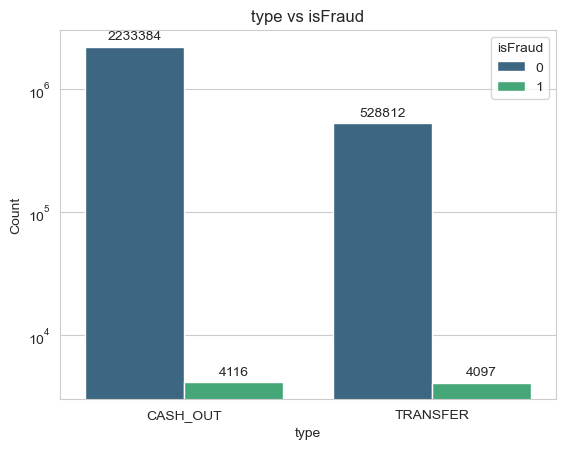

In [25]:
viz_type = DataVisualizer(df)
viz_type.countplots_type('type','isFraud')

**Insights:**  
* **Paired Transactions:** The number of frauds in `TRANSFER` (4,097) and `CASH_OUT` (4,116) is almost identical. This strongly suggests a pattern: fraudsters first transfer the stolen money to another account, and then immediately cash it out.
* **Relative Risk:** Even though fraud is very rare in the dataset, a `TRANSFER` is statistically 4 times more likely to be a fraud than a `CASH_OUT` (0.77% vs 0.19%). This significant difference makes the transaction type an important feature for the models.

### 4.3.2 `step` vs `isFraud`

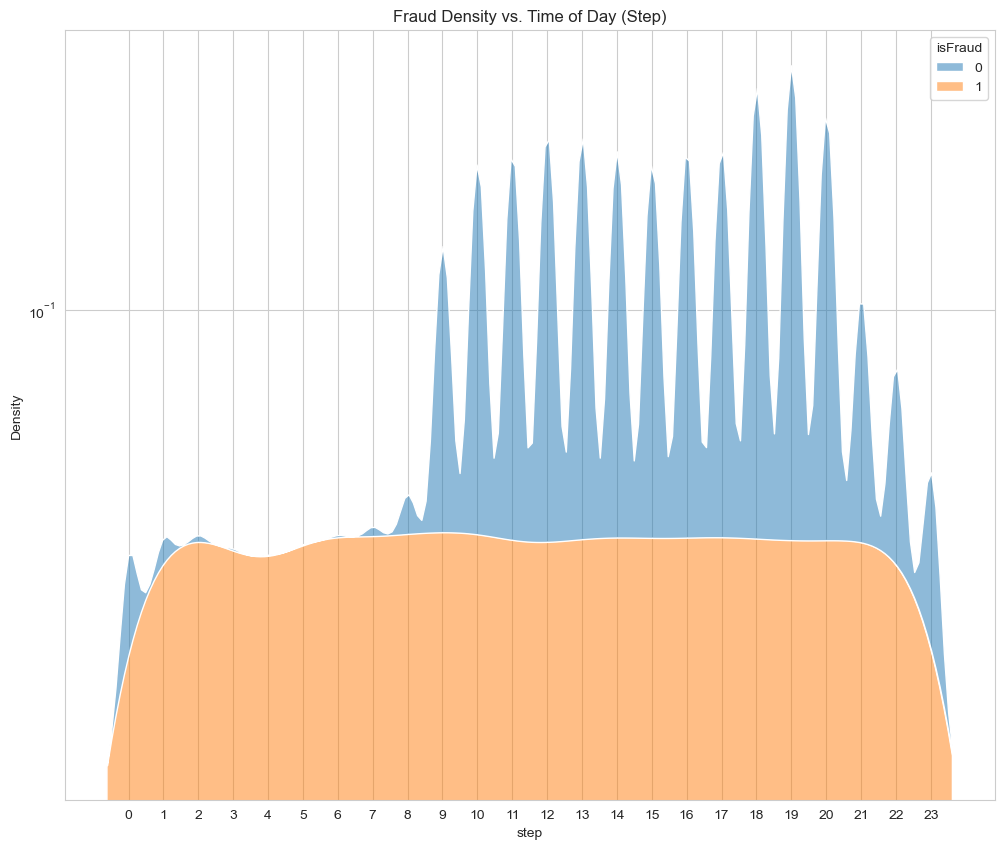

In [26]:
df['hour_of_day'] = df['step'] % 24
step_viz = DataVisualizer(df)
step_viz.kdeplot('hour_of_day','isFraud')

**Insights:**  
* **Normal Human Rhythm:** Genuine transactions (`isFraud=0`) follow a natural daily routine. Activity peaks during standard waking hours (9:00 AM - 8:00 PM) and significantly drops during the night.
* **24/7 Fraud Operations:** Fraudulent transactions (`isFraud=1`) are distributed almost evenly across the entire 24-hour cycle. This flat distribution suggests automated attacks (using bots/scripts) or organized groups operating from different time zones.
* **Nighttime Risk:** Because genuine traffic drops at night while fraud volume remains steady, late-night transactions carry a significantly higher probability of being fraudulent.


### 4.3.3 `amount` vs `isFraud`

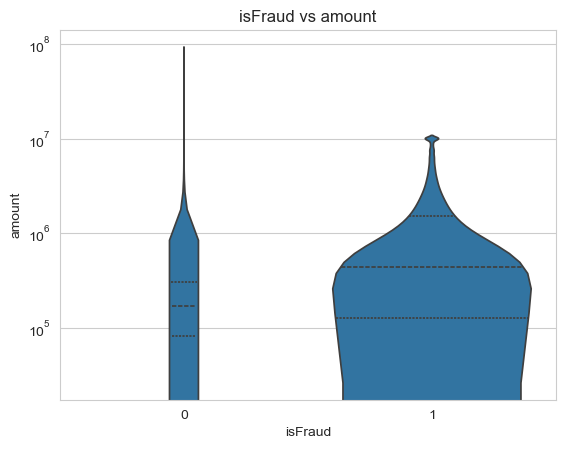

In [27]:
amount_viz = DataVisualizer(df)
amount_viz.violinplot('amount','isFraud')

**Insights:**  
* **Distribution Shape & Center of Mass:** Genuine transactions (`isFraud=0`) are predominantly concentrated at lower values, with their density steadily decreasing as the amount grows. In contrast, fraudulent transactions (`isFraud=1`) cover a much wider range. While low-value frauds occur frequently, the overall center of mass is shifted significantly higher compared to genuine transactions.
* **Typical Fraud Value:** The widest part of the fraud distribution lies halfway between $10^5$ and $10^6$ on the logarithmic scale.
* **The 10 Million Limit:** A distinct spike in fraud occurs exactly at the $10^7$ mark. This indicates systematic attempts to drain accounts up to a hard system limit.

### 4.3.4 `isFraud` vs `errors`

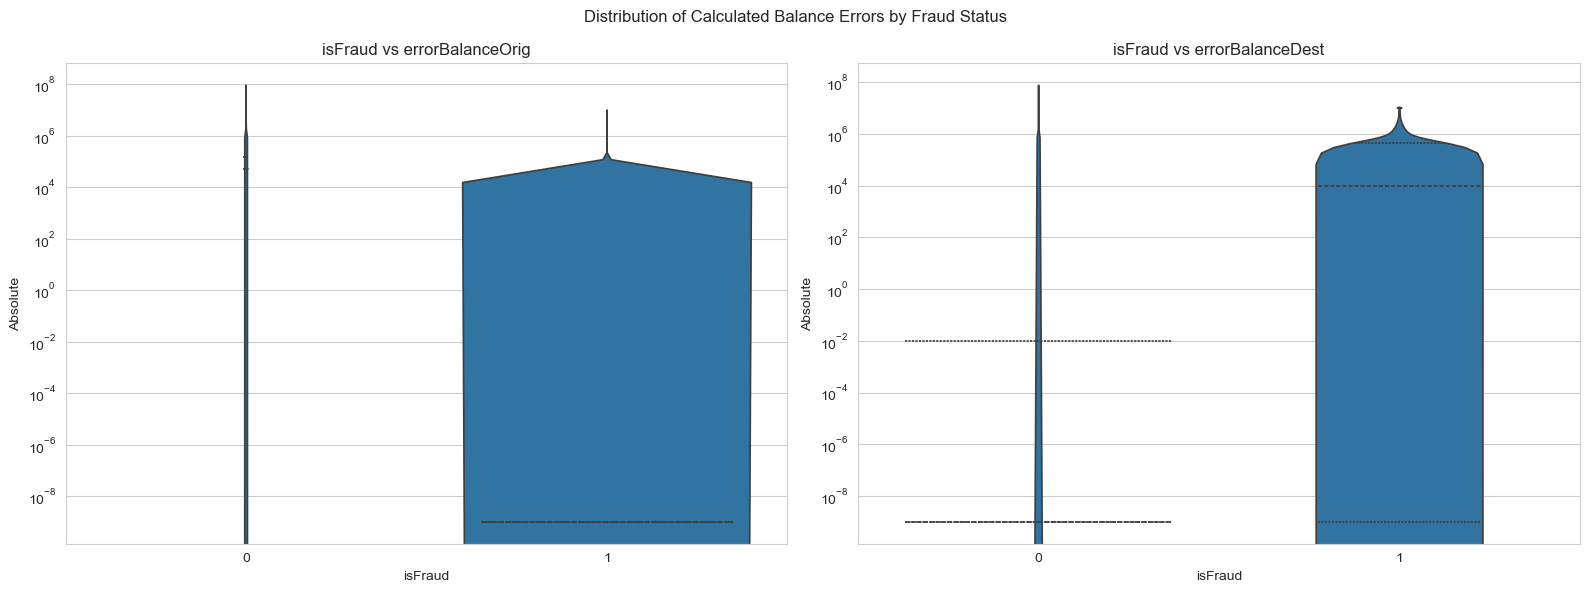

In [28]:
error_cols = df[['errorBalanceOrig', 'errorBalanceDest']]
viz_error = DataVisualizer(df)
viz_error.violinplot_error('isFraud',error_cols,'Distribution of Calculated Balance Errors by Fraud Status',1,2)

**Insights:**  
1. **Sender Account Balance Error (`errorBalanceOrig`) vs. isFraud Analysis:**
   * **Strong Predictor:** This chart visually proves that the engineered feature `errorBalanceOrig` is a near-perfect separator for the classes.
   * **Flawless Accounting in Normal Behavior:** Genuine transactions (`isFraud=0`) display zero mathematical error between the transaction amount and the pre/post balances. This is represented by the razor-thin vertical line, confirming system integrity for normal users.
   * **Systemic Anomalies in Frauds:** Fraudulent transactions (`isFraud=1`) consistently break the expected accounting logic, generating massive discrepancies across multiple orders of magnitude.

2. **Destination Account Balance Error (`errorBalanceDest`) vs. isFraud Analysis:**
  * **Confirmation of Systemic Flaw:** This chart acts as a mirror to the originator error analysis. It proves that the mathematical anomaly during a fraudulent event affects the entire transaction chain, not just the sender's account.
  * **Accounting Consistency for Normal Users:** For genuine transactions (`isFraud=0`), the destination account balances reconcile perfectly (`oldBalanceDest + amount = newBalanceDest`). The absolute error is virtually zero (represented by the thin line dropping to microscopic fractions like $10^{-8}$, which is just floating-point noise).
* **Massive Discrepancies in Frauds:** Just like the sender's side, fraudulent transactions (`isFraud=1`) completely break the accounting logic on the receiving end. The massive, wide block indicates massive unrecorded balances or missing funds at the destination. Combining both originator and destination errors gives the ML models an undeniable signature of fraud.




# 5. Feature Engineering

## 5.1 Time-Based Features

Extracting the hour of the day and day of the week from the continous `step` variable to capture daily activity cycles and nighttime fraud anomalies.

In [29]:
df['hour_of_day'] = df['step'] % 24
df['day_of_week'] = (df['step'] // 24) % 7

## 5.2 Account Draining Indicator

Creating a binary flag for transactions that completely empty the origin account `newbalanceOrig = 0`, which is a strong behavioral pattern among fraudsters.

In [30]:
df['accountDrained'] = ((df['newbalanceOrig'] == 0) & (df['amount'] > 0)).astype(int)

In [31]:
df['accountDrained'].value_counts()

accountDrained
1    2496640
0     273769
Name: count, dtype: int64

In [32]:
print(pd.crosstab(df['accountDrained'], df['isFraud']))

isFraud               0     1
accountDrained               
0                273593   176
1               2488603  8037


## 5.3 High-Value Transaction Flag

Flagging extreme transaction values by isolating the top 5% of the `amount` distribution, helping the model identyfi unnaturally large potentially fraudulent transfer.

In [33]:
threshold = df['amount'].quantile(0.95)
df['isHighAmount'] = (df['amount'] > threshold).astype(int)

In [34]:
df['isHighAmount'].value_counts()

isHighAmount
0    2631888
1     138521
Name: count, dtype: int64

In [35]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,hour_of_day,day_of_week,accountDrained,isHighAmount
0,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0.00,181.0,1,0,1,0
1,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0.00,21363.0,1,0,1,0
2,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,-213808.94,182703.5,1,0,1,0
3,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,-214605.30,237735.3,1,0,1,0
4,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,-300850.89,-2401220.0,1,0,1,0


# 6. Save Data

In [ ]:
df.to_csv('clean_data.csv', index=False)